# FASE 2: Entrenamiento del modelo

Este notebook carga los datos preparados en la Fase 1 desde el archivo:

`datos_fase1_accidentes_cuenca.pkl`

Por eso, antes de ejecutar esta fase, debes ejecutar completa la Fase 1 final corregida.


## 1. Importación de librerías

In [26]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [27]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(Y_train),
    y=Y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.947209653092006), 1: np.float64(0.880027266530334), 2: np.float64(0.7406769936890418)}


## 2. Cargar datos generados en la Fase 1

In [28]:
with open("datos_fase1_accidentes_cuenca.pkl", "rb") as archivo:
    datos = pickle.load(archivo)

print("Tipo de archivo cargado:", type(datos))

print("Claves disponibles:")
print(datos.keys())

Tipo de archivo cargado: <class 'dict'>
Claves disponibles:
dict_keys(['X_train_transformado', 'X_test_transformado', 'Y_train', 'Y_test', 'label_encoder', 'preprocesador', 'columnas_entrada', 'variables_numericas', 'variables_categoricas'])


In [29]:
X_train_transformado = datos["X_train_transformado"]
X_test_transformado = datos["X_test_transformado"]
Y_train = datos["Y_train"]
Y_test = datos["Y_test"]
label_encoder = datos["label_encoder"]
preprocesador = datos["preprocesador"]

print("Datos cargados correctamente.")
print("X_train_transformado:", X_train_transformado.shape)
print("X_test_transformado:", X_test_transformado.shape)
print("Y_train:", Y_train.shape)
print("Y_test:", Y_test.shape)
print("Clases:", label_encoder.classes_)

Datos cargados correctamente.
X_train_transformado: (1291, 82)
X_test_transformado: (323, 82)
Y_train: (1291,)
Y_test: (323,)
Clases: ['ALTO' 'BAJO' 'MEDIO']


## 3. Conversión de la variable objetivo a formato categórico

In [30]:
label_encoder = LabelEncoder()

Y_train = label_encoder.fit_transform(Y_train)
Y_test = label_encoder.transform(Y_test)

print("Clases:", label_encoder.classes_)
print("Y_train codificado:", Y_train[:10])
print("Y_test codificado:", Y_test[:10])

Clases: ['ALTO' 'BAJO' 'MEDIO']
Y_train codificado: [1 0 2 2 2 1 1 1 2 1]
Y_test codificado: [2 1 2 0 2 2 2 0 1 1]


In [31]:
Y_train_cat = to_categorical(Y_train)
Y_test_cat = to_categorical(Y_test)

print("Y_train_cat:", Y_train_cat.shape)
print("Y_test_cat:", Y_test_cat.shape)

Y_train_cat: (1291, 3)
Y_test_cat: (323, 3)


## 4. Definir entradas y salidas de la red neuronal

In [32]:
n_entradas = X_train_transformado.shape[1]
n_clases = Y_train_cat.shape[1]

print("Número de entradas:", n_entradas)
print("Número de clases:", n_clases)

Número de entradas: 82
Número de clases: 3


## 5. Crear la Red Neuronal Artificial

In [33]:
modelo = Sequential()

modelo.add(Dense(64, activation="relu", input_shape=(n_entradas,)))
modelo.add(Dropout(0.40))

modelo.add(Dense(32, activation="relu"))
modelo.add(Dropout(0.30))

modelo.add(Dense(n_clases, activation="softmax"))

modelo.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

c:\Users\avila\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 6. Compilar el modelo

In [34]:
modelo.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

modelo.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         5,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,491 (29.26 KB)

 Trainable params: 7,491 (29.26 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Configurar EarlyStopping

In [35]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

## 8. Entrenar el modelo

In [36]:
historial = modelo.fit(
    X_train_transformado,
    Y_train_cat,
    validation_split=0.20,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3120 - loss: 1.1534 - val_accuracy: 0.3668 - val_loss: 1.0979
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3488 - loss: 1.0993 - val_accuracy: 0.4788 - val_loss: 1.0753
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4341 - loss: 1.0849 - val_accuracy: 0.5212 - val_loss: 1.0544
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4835 - loss: 1.0580 - val_accuracy: 0.5097 - val_loss: 1.0306
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 1.0435 - val_accuracy: 0.5212 - val_loss: 1.0181
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5126 - loss: 1.0212 - val_accuracy: 0.5753 - val_loss: 0.9765
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5610 - loss: 0.9972 - val_accuracy: 0.5869 - val_loss: 0.9631
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5252 - loss: 0.9863 - val_accuracy: 0.5367 - 

## 9. Evaluar el modelo

In [37]:
loss, accuracy = modelo.evaluate(
    X_test_transformado,
    Y_test_cat,
    verbose=0
)

print("Loss:", loss)
print("Accuracy:", accuracy)

Loss: 0.9384385943412781
Accuracy: 0.5356037020683289


## 10. Gráfica de accuracy

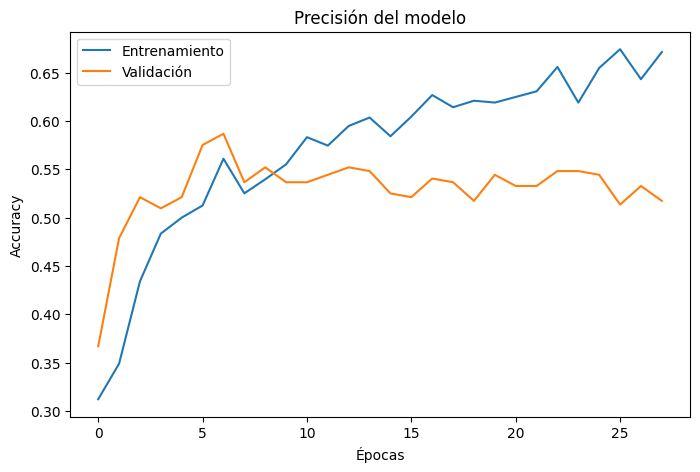

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(historial.history["accuracy"], label="Entrenamiento")
plt.plot(historial.history["val_accuracy"], label="Validación")
plt.title("Precisión del modelo")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 11. Gráfica de pérdida

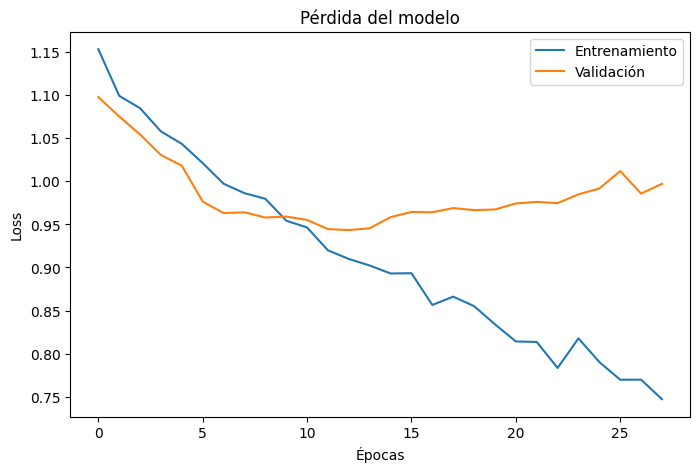

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(historial.history["loss"], label="Entrenamiento")
plt.plot(historial.history["val_loss"], label="Validación")
plt.title("Pérdida del modelo")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 12. Predicciones

In [40]:
predicciones_probabilidad = modelo.predict(X_test_transformado)
predicciones = np.argmax(predicciones_probabilidad, axis=1)

print("Primeras predicciones:", predicciones[:10])
print("Primeros valores reales:", Y_test[:10])

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Primeras predicciones: [1 1 0 1 2 1 2 0 2 1]
Primeros valores reales: [2 1 2 0 2 2 2 0 1 1]


## 13. Matriz de confusión

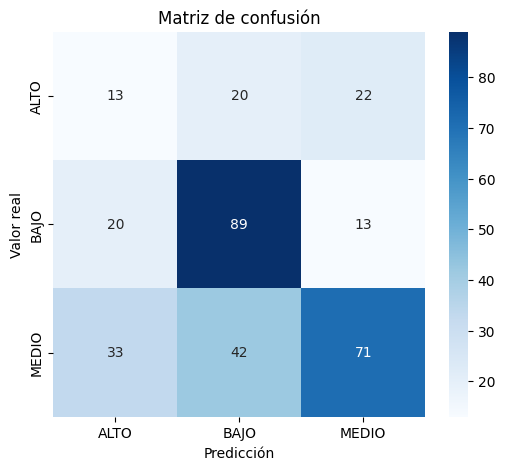

In [41]:
cm = confusion_matrix(Y_test, predicciones)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

## 14. Reporte de clasificación

In [42]:
print(classification_report(
    Y_test,
    predicciones,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

        ALTO       0.20      0.24      0.21        55
        BAJO       0.59      0.73      0.65       122
       MEDIO       0.67      0.49      0.56       146

    accuracy                           0.54       323
   macro avg       0.49      0.48      0.48       323
weighted avg       0.56      0.54      0.54       323



## 15. Guardar modelo entrenado

In [43]:
modelo.save("modelo_accidentes_cuenca.keras")

with open("historial_modelo_accidentes_cuenca.pkl", "wb") as archivo:
    pickle.dump(historial.history, archivo)

print("Modelo e historial guardados correctamente.")

Modelo e historial guardados correctamente.
